In [2]:
# ==============================================
# Imports y configuración global
# ==============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings

# Silenciar advertencias de librerías
warnings.filterwarnings('ignore')

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.autolayout'] = True 

print("✔ Librerías cargadas y entorno configurado correctamente")

✔ Librerías cargadas y entorno configurado correctamente


In [3]:
# Ruta absoluta basada en ubicación del notebook
DATA_PATH = Path.cwd().parent / "Base_de_datos.csv"

# Verificación
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset en: {DATA_PATH}")

# Lectura robusta
df = pd.read_csv(
    DATA_PATH,
    encoding="latin-1",     # datasets latam casi siempre
    sep=",",                # cambiá a ";" si hiciera falta
    engine="python",
    on_bad_lines="warn"
)

print("✔ Dataset cargado correctamente")
print("Shape:", df.shape)

display(df.head())

print("\n--- INFO ---")
display(df.info())

✔ Dataset cargado correctamente
Shape: (10763, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,12/21/24 11:31,3692160,10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,4/22/25 9:47,840000,6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,1/8/26 12:22,5974028,10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0
3,4,8/4/25 12:04,1671240,6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1
4,9,4/26/25 11:24,2781636,11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1



--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  object 
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  object 
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                1

None

In [4]:
# ==============================================
# 1. Caracterización Avanzada (V 1.0.1)
# ==============================================

from pandas.api.types import is_numeric_dtype, is_datetime64_any_dtype, is_bool_dtype

def caracterizar_dataset_pro(df):
    # Definimos manualmente las que sabemos por negocio que son ORDINALES
    # (Tienen un orden lógico: Bajo < Medio < Alto)
    cols_ordinales = ['tipo_credito', 'tendencia_ingresos']
    
    resumen = []
    
    for col in df.columns:
        n_unique = df[col].nunique()
        dtype = df[col].dtype
        
        # 1. Identificación del Tipo Estadístico
        if col == 'Pago_atiempo' or is_bool_dtype(df[col]):
            tipo_stats = "Dicotómica (Target/Bool)"
        
        elif col in cols_ordinales:
            tipo_stats = "Categórica Ordinal"
            
        elif is_datetime64_any_dtype(df[col]):
            tipo_stats = "Temporal"
            
        elif is_numeric_dtype(df[col]):
            # Solo si tiene muy pocos valores Y no es flotante, podría ser discreta
            if n_unique < 12 and not any(isinstance(x, float) for x in df[col].dropna().unique()):
                tipo_stats = "Numérica Discreta"
            else:
                tipo_stats = "Numérica Continua"
        else:
            tipo_stats = "Categórica Nominal"
            
        resumen.append({
            'Columna': col,
            'Dtype_Actual': str(dtype),
            'Tipo_Estadistico': tipo_stats,
            'Valores_Unicos': n_unique,
            '%_Nulos': (df[col].isnull().sum() / len(df)) * 100 if len(df) > 0 else 0
        })
        
    return pd.DataFrame(resumen)

# Ejecutamos la nueva caracterización
df_resumen = caracterizar_dataset_pro(df)
display(df_resumen)

,Columna,Dtype_Actual,Tipo_Estadistico,Valores_Unicos,%_Nulos
0,tipo_credito,int64,Categórica Ordinal,6,0.00
1,fecha_prestamo,object,Categórica Nominal,10444,0.00
2,capital_prestado,int64,Numérica Continua,7306,0.00
3,plazo_meses,int64,Numérica Continua,18,0.00
4,edad_cliente,int64,Numérica Continua,54,0.00
5,tipo_laboral,object,Categórica Nominal,2,0.00
6,salario_cliente,int64,Numérica Continua,1385,0.00
7,total_otros_prestamos,int64,Numérica Continua,1538,0.00
8,cuota_pactada,int64,Numérica Continua,9836,0.00
9,puntaje,float64,Numérica Continua,248,0.00


In [5]:
# ==============================================
# BLOQUE MAESTRO: Limpieza, Tipado y Caracterización (CORREGIDO)
# ==============================================
import pandas as pd
import numpy as np
from pandas.api.types import is_numeric_dtype, is_datetime64_any_dtype, is_bool_dtype

print("=== INICIO DEL PROCESAMIENTO ROBUSTO ===")

# ---------------------------------------------------------
# 1. DEFINICIÓN DE LISTAS DE CONTROL
# ---------------------------------------------------------
# Definimos roles explícitos para no mezclar peras con manzanas
target_col = 'Pago_atiempo'

# Nulos que SÍ queremos borrar (basura informática)
# OJO: Sacamos 'Sin dato', 'Desconocido', etc., porque eso es información de negocio.
nulos_reales = ['', ' ', '-', 'nan', 'NaN', 'NAN', 'null', 'NULL', 'None', 'none', 'N/A', 'NA', 'n/a']

# ---------------------------------------------------------
# 2. LIMPIEZA DE NULOS (Paso 1: Antes de tipar)
# ---------------------------------------------------------
nulos_antes = df.isnull().sum().sum()
df.replace(nulos_reales, np.nan, inplace=True)
print(f"✔ Limpieza de basura ejecutada. Nulos ocultos detectados: {df.isnull().sum().sum() - nulos_antes}")

# ---------------------------------------------------------
# 3. TRATAMIENTO DEL TARGET (La variable sagrada)
# ---------------------------------------------------------
# Se fuerza a booleano o entero. Asumimos que viene como 1/0 o '1'/'0'.
# Si hay nulos en el target, esas filas NO SIRVEN para entrenar, se borran o analizan.
df.dropna(subset=[target_col], inplace=True) # Seguridad extrema
df[target_col] = df[target_col].astype(int).astype(bool) # Asegura 0/1 -> False/True
print(f"✔ Target '{target_col}' blindado como bool.")

# ---------------------------------------------------------
# 4. TIPADO DE VARIABLES
# ---------------------------------------------------------

# A) Fechas
if 'fecha_prestamo' in df.columns:
    df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'], errors='coerce')

# B) Categóricas y Ordinales (Excluyendo explícitamente el target)
cols_categoricas = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos']
# Agregamos las que detectemos que son texto pero no fechas
for col in cols_categoricas:
    if col in df.columns:
        df[col] = df[col].astype('category')

# C) Numéricas (El resto)
# Lógica inversa segura: Todo lo que no es fecha, ni categoría, ni target, ni bool
cols_reservadas = cols_categoricas + ['fecha_prestamo', target_col]
cols_numericas = [c for c in df.columns if c not in cols_reservadas]

for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("✔ Tipado de variables finalizado correctamente.")

# ---------------------------------------------------------
# 5. CARACTERIZACIÓN ESTADÍSTICA (Función Corregida)
# ---------------------------------------------------------
def caracterizar_dataset_final(df):
    resumen = []
    
    # Definimos ordinales por conocimiento de negocio
    cols_ordinales = ['tipo_credito', 'tendencia_ingresos']
    
    for col in df.columns:
        n_unique = df[col].nunique()
        dtype = df[col].dtype
        
        # Lógica de clasificación corregida por el profesor
        if col == target_col:
            tipo_stats = "Target (Dicotómica)"
        elif is_bool_dtype(df[col]):
            tipo_stats = "Booleana"
        elif is_datetime64_any_dtype(df[col]):
            tipo_stats = "Temporal"
        elif col in cols_ordinales:
            tipo_stats = "Categórica Ordinal"
        elif isinstance(dtype, pd.CategoricalDtype) or dtype == object:
            tipo_stats = "Categórica Nominal"
        elif is_numeric_dtype(df[col]):
            # VALIDACIÓN MATEMÁTICA CORRECTA para discretas (enteros disfrazados de float)
            # Si todos los valores tienen residuo 0 al dividir por 1, son enteros.
            es_entero_matematico = df[col].dropna().mod(1).eq(0).all()
            
            if es_entero_matematico and n_unique <= 20:
                tipo_stats = "Numérica Discreta"
            else:
                tipo_stats = "Numérica Continua"
        else:
            tipo_stats = "Otro"
            
        resumen.append({
            'Columna': col,
            'Tipo_Pandas': str(dtype),
            'Tipo_Estadistico': tipo_stats,
            'Valores_Unicos': n_unique,
            '%_Nulos': round((df[col].isnull().sum() / len(df)) * 100, 2)
        })
    
    return pd.DataFrame(resumen)

# Ejecutar caracterización DESPUÉS de limpiar
print("\n--- CARACTERIZACIÓN FINAL DEL DATASET ---")
df_resumen = caracterizar_dataset_final(df)
display(df_resumen)

# ---------------------------------------------------------
# 6. VERIFICACIÓN FINAL
# ---------------------------------------------------------
print("\nVerificación de integridad:")
print(f"Target dtype: {df[target_col].dtype}")
print(f"Total filas: {len(df)}")

=== INICIO DEL PROCESAMIENTO ROBUSTO ===
✔ Limpieza de basura ejecutada. Nulos ocultos detectados: 0
✔ Target 'Pago_atiempo' blindado como bool.
✔ Tipado de variables finalizado correctamente.

--- CARACTERIZACIÓN FINAL DEL DATASET ---


,Columna,Tipo_Pandas,Tipo_Estadistico,Valores_Unicos,%_Nulos
0,tipo_credito,category,Categórica Ordinal,6,0.00
1,fecha_prestamo,datetime64[ns],Temporal,10444,0.00
2,capital_prestado,int64,Numérica Continua,7306,0.00
3,plazo_meses,int64,Numérica Discreta,18,0.00
4,edad_cliente,int64,Numérica Continua,54,0.00
5,tipo_laboral,category,Categórica Nominal,2,0.00
6,salario_cliente,int64,Numérica Continua,1385,0.00
7,total_otros_prestamos,int64,Numérica Continua,1538,0.00
8,cuota_pactada,int64,Numérica Continua,9836,0.00
9,puntaje,float64,Numérica Continua,248,0.00



Verificación de integridad:
Target dtype: bool
Total filas: 10763


In [6]:
# ==============================================
# 5. Imputación Estratégica Semántica (CORREGIDA)
# ==============================================
print("=== APLICANDO IMPUTACIÓN SEMÁNTICA (Credit Scoring) ===")

# --- A) CATEGÓRICAS ---
cols_cat = df.select_dtypes(include=['category']).columns.tolist()
if target_col in cols_cat: cols_cat.remove(target_col)

for col in cols_cat:
    if df[col].isnull().any():
        if "Desconocido" not in df[col].cat.categories:
            df[col] = df[col].cat.add_categories(["Desconocido"])
        df[col] = df[col].fillna("Desconocido")
        print(f"✔ {col}: imputado como 'Desconocido'")


# =====================================================
# --- B) NUMÉRICAS: Tratamiento especializado scoring
# =====================================================

# 1) SCORES CREDITICIOS → riesgo alto + flag thin-file
score_cols = ['puntaje_datacredito', 'puntaje']

for col in score_cols:
    if col in df.columns and df[col].isnull().any():
        df[f'{col}_sin_historial'] = df[col].isnull().astype(int)
        imput_val = df[col].quantile(0.05)  # penalización realista
        df[col] = df[col].fillna(imput_val)
        print(f"✔ {col}: imputado con p5 ({imput_val:.2f}) + flag thin-file")


# 2) Ausencia estructural → 0
cols_zero = [
    'saldo_mora', 'saldo_mora_codeudor', 'total_otros_prestamos', 
    'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 
    'creditos_sectorReal', 'huella_consulta', 'cant_creditosvigentes'
]

for col in cols_zero:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(0)
        print(f"✔ {col}: imputado 0 (ausencia financiera)")


# 3) Mediana → continuas monetarias
cols_mediana = [
    'salario_cliente', 'promedio_ingresos_datacredito', 
    'saldo_total', 'saldo_principal', 
    'capital_prestado', 'cuota_pactada'
]

for col in cols_mediana:
    if col in df.columns and df[col].isnull().any():
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f"✔ {col}: imputado con mediana ({med:.2f})")


# 4) Moda → discretas
cols_moda = ['plazo_meses', 'edad_cliente']

for col in cols_moda:
    if col in df.columns and df[col].isnull().any():
        mode_val = df[col].mode(dropna=True)[0]   # <- optimizado
        df[col] = df[col].fillna(mode_val)
        print(f"✔ {col}: imputado con moda ({mode_val})")


# --- Verificación Final ---
nulos_finales = df.isnull().sum().sum()
print(f"\nNulos restantes en el dataset: {nulos_finales}")

if nulos_finales == 0:
    print("Dataset listo y limpio para el análisis descriptivo (EDA).")


=== APLICANDO IMPUTACIÓN SEMÁNTICA (Credit Scoring) ===
✔ tendencia_ingresos: imputado como 'Desconocido'
✔ puntaje_datacredito: imputado con p5 (710.00) + flag thin-file
✔ saldo_mora: imputado 0 (ausencia financiera)
✔ saldo_mora_codeudor: imputado 0 (ausencia financiera)
✔ promedio_ingresos_datacredito: imputado con mediana (1204496.00)
✔ saldo_total: imputado con mediana (16178.00)
✔ saldo_principal: imputado con mediana (14442.50)

Nulos restantes en el dataset: 0
🚀 Dataset listo y limpio para el análisis descriptivo (EDA).


In [7]:
df.isnull().sum()

tipo_credito                         0
fecha_prestamo                       0
capital_prestado                     0
plazo_meses                          0
edad_cliente                         0
tipo_laboral                         0
salario_cliente                      0
total_otros_prestamos                0
cuota_pactada                        0
puntaje                              0
puntaje_datacredito                  0
cant_creditosvigentes                0
huella_consulta                      0
saldo_mora                           0
saldo_total                          0
saldo_principal                      0
saldo_mora_codeudor                  0
creditos_sectorFinanciero            0
creditos_sectorCooperativo           0
creditos_sectorReal                  0
promedio_ingresos_datacredito        0
tendencia_ingresos                   0
Pago_atiempo                         0
puntaje_datacredito_sin_historial    0
dtype: int64

In [14]:
# ==============================================
# LIMPIEZA SEMÁNTICA DE VARIABLES DE NEGOCIO
# ==============================================

print("=== VALIDACIÓN DE DOMINIO (ANTES DE IMPUTAR) ===")

# --------------------------------------------------
# 1) tipo_credito → ENUMERACIÓN CERRADA
# --------------------------------------------------
if 'tipo_credito' in df.columns:

    # forzamos lectura limpia
    df['tipo_credito'] = pd.to_numeric(df['tipo_credito'], errors='coerce')

    valores_validos = set(range(1,11))  # ajustar si negocio lo define distinto

    mask_invalid = ~df['tipo_credito'].isin(valores_validos)
    print("Registros corruptos tipo_credito:", mask_invalid.sum())

    df.loc[mask_invalid, 'tipo_credito'] = np.nan

    df['tipo_credito'] = df['tipo_credito'].astype('Int64').astype('category')

    print(df['tipo_credito'].value_counts(dropna=False))


# --------------------------------------------------
# 2) tendencia_ingresos → CATEGORÍA PURA
# --------------------------------------------------
if 'tendencia_ingresos' in df.columns:

    df['tendencia_ingresos'] = (
        df['tendencia_ingresos']
        .astype(str)
        .str.strip()
        .str.lower()
    )

    mapping = {
        'creciente':'Creciente',
        'estable':'Estable',
        'decreciente':'Decreciente'
    }

    df['tendencia_ingresos'] = df['tendencia_ingresos'].map(mapping)

    corruptos = df['tendencia_ingresos'].isna().sum()
    print("Registros corruptos tendencia_ingresos:", corruptos)

    df['tendencia_ingresos'] = pd.Categorical(
        df['tendencia_ingresos'],
        categories=['Decreciente','Estable','Creciente'],
        ordered=True
    )

    print(df['tendencia_ingresos'].value_counts(dropna=False))


=== VALIDACIÓN DE DOMINIO (ANTES DE IMPUTAR) ===
Registros corruptos tipo_credito: 1
tipo_credito
4      7747
9      2876
10      116
6        21
7         2
NaN       1
Name: count, dtype: int64
Registros corruptos tendencia_ingresos: 2990
tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64


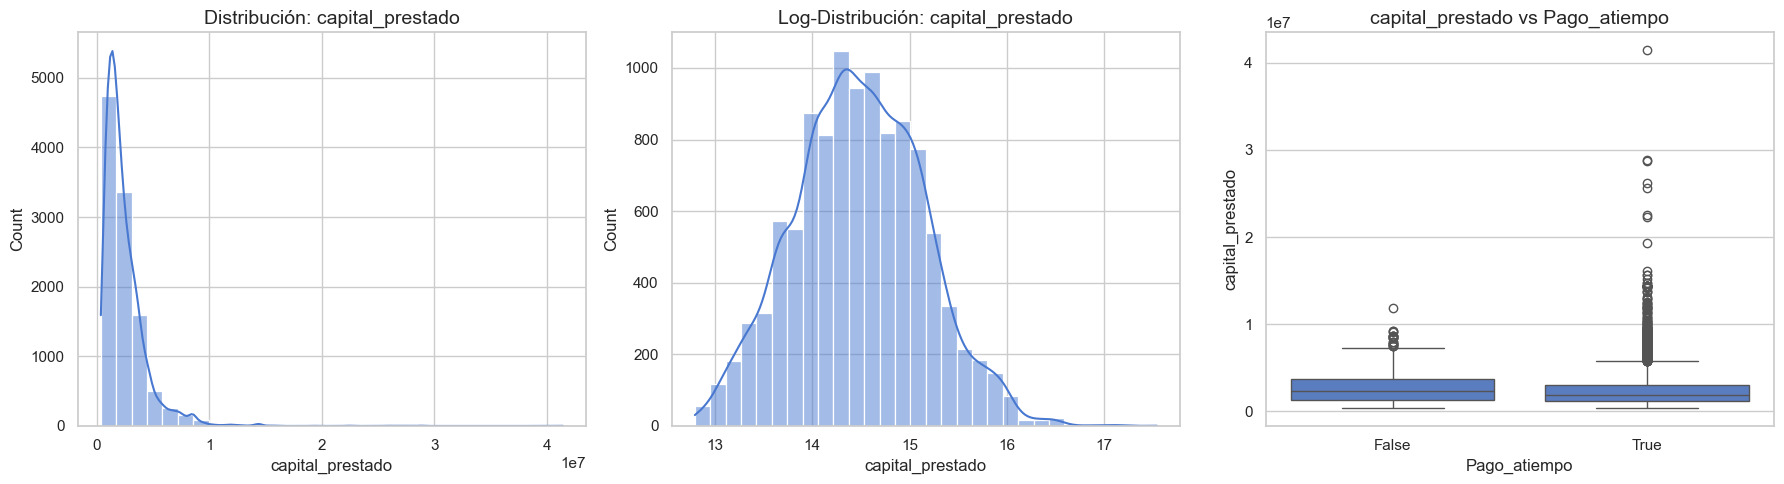


--- Estadísticas de capital_prestado ---
count       10,763.00
mean     2,434,315.00
std      1,909,642.76
min        360,000.00
25%      1,224,831.00
50%      1,921,920.00
75%      3,084,840.00
max     41,444,153.00
Skewness: 3.72
Kurtosis: 35.32
% Outliers (método IQR): 5.11%


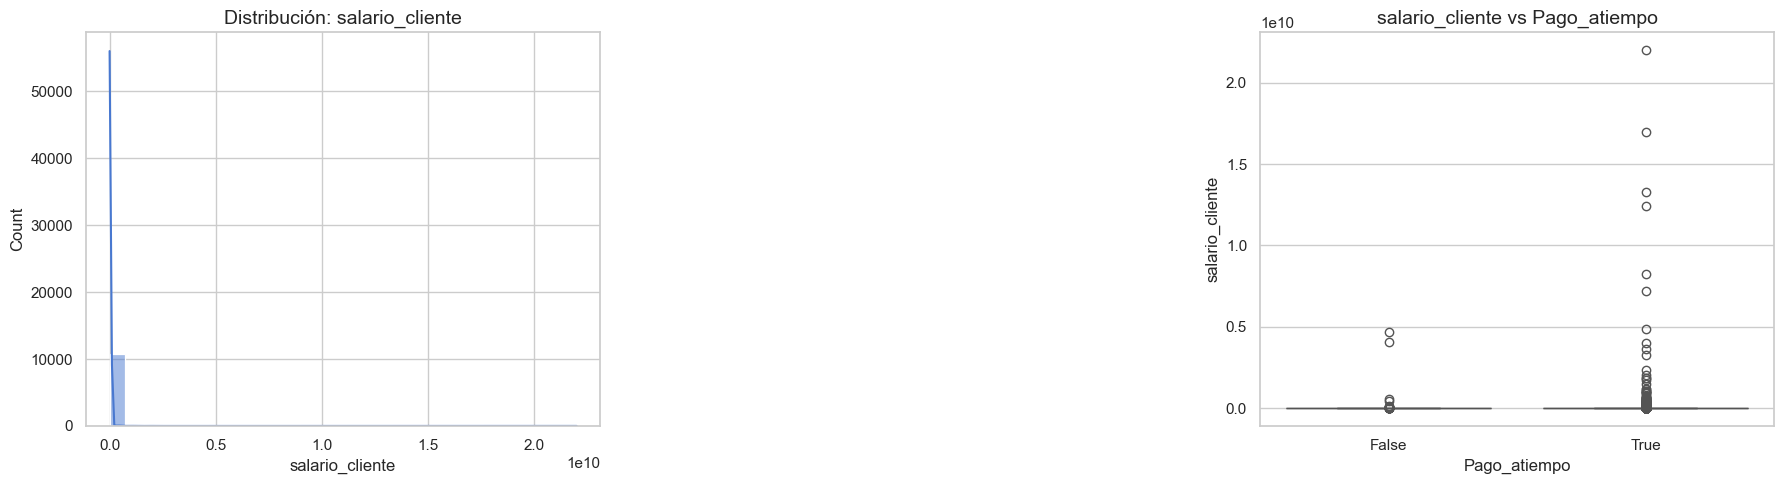


--- Estadísticas de salario_cliente ---
count           10,763.00
mean        17,216,431.46
std        355,476,717.60
min                  0.00
25%          2,000,000.00
50%          3,000,000.00
75%          4,875,808.00
max     22,000,000,000.00
Skewness: 43.78
Kurtosis: 2211.23
% Outliers (método IQR): 6.67%


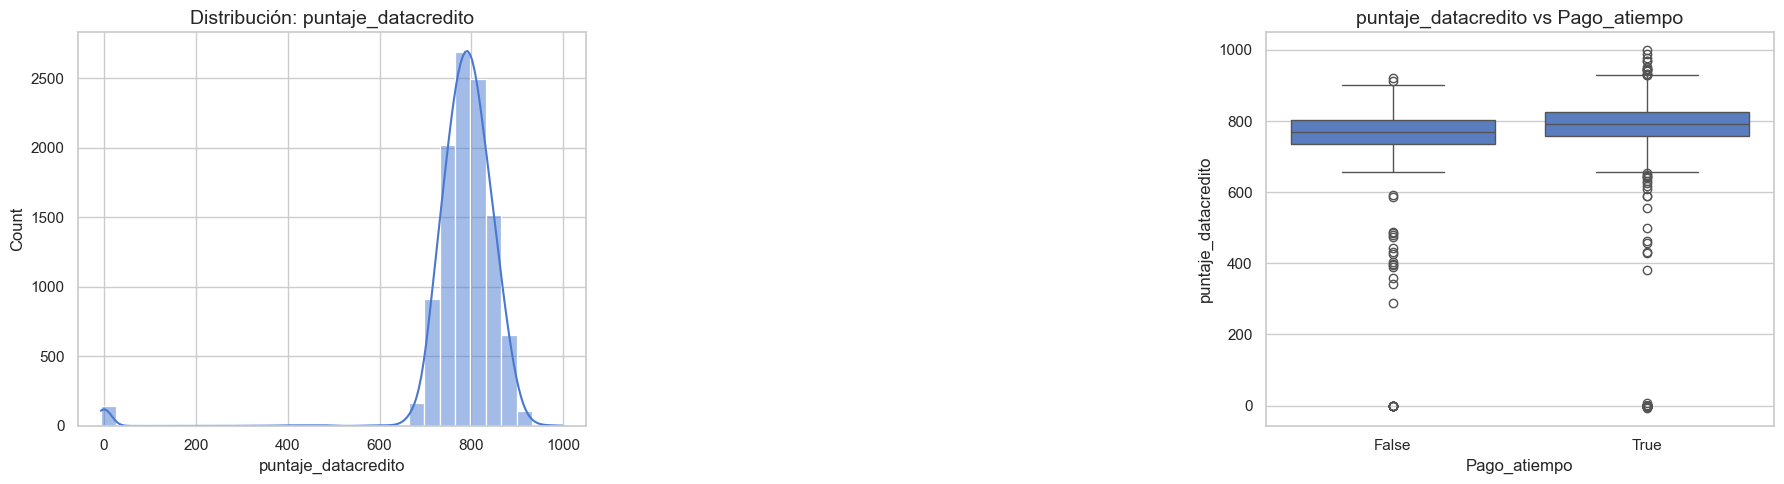


--- Estadísticas de puntaje_datacredito ---
count   10,763.00
mean       780.75
std        104.86
min         -7.00
25%        757.00
50%        791.00
75%        825.00
max        999.00
Skewness: -5.64
Kurtosis: 39.43
% Outliers (método IQR): 1.82%


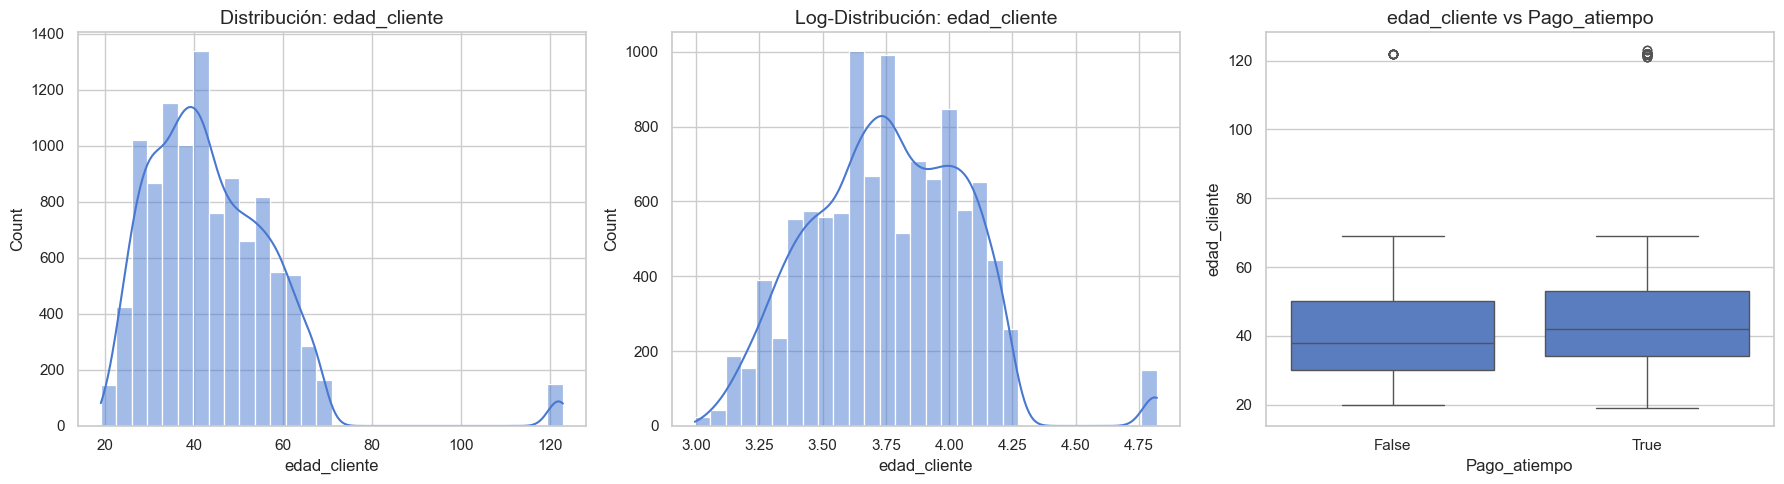


--- Estadísticas de edad_cliente ---
count   10,763.00
mean        43.95
std         15.06
min         19.00
25%         33.00
50%         42.00
75%         53.00
max        123.00
Skewness: 1.93
Kurtosis: 7.87
% Outliers (método IQR): 1.39%


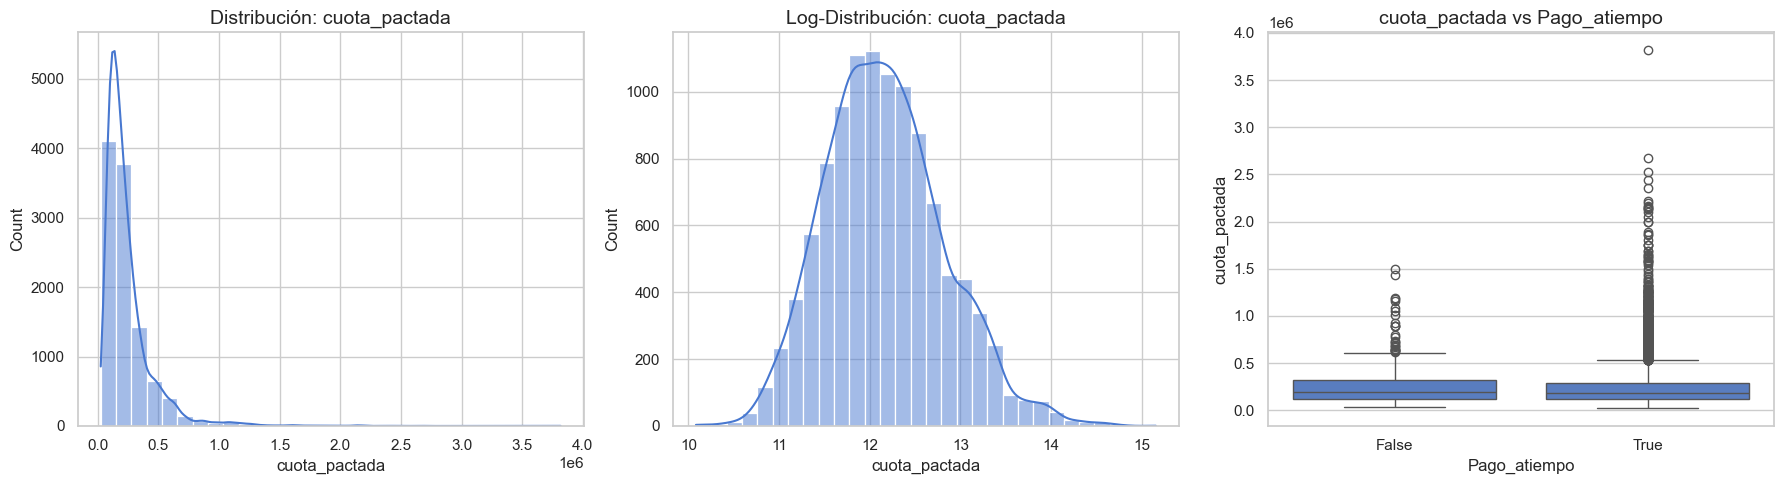


--- Estadísticas de cuota_pactada ---
count      10,763.00
mean      243,617.41
std       210,493.69
min        23,944.00
25%       121,041.50
50%       182,863.00
75%       287,833.50
max     3,816,752.00
Skewness: 3.79
Kurtosis: 26.65
% Outliers (método IQR): 7.11%


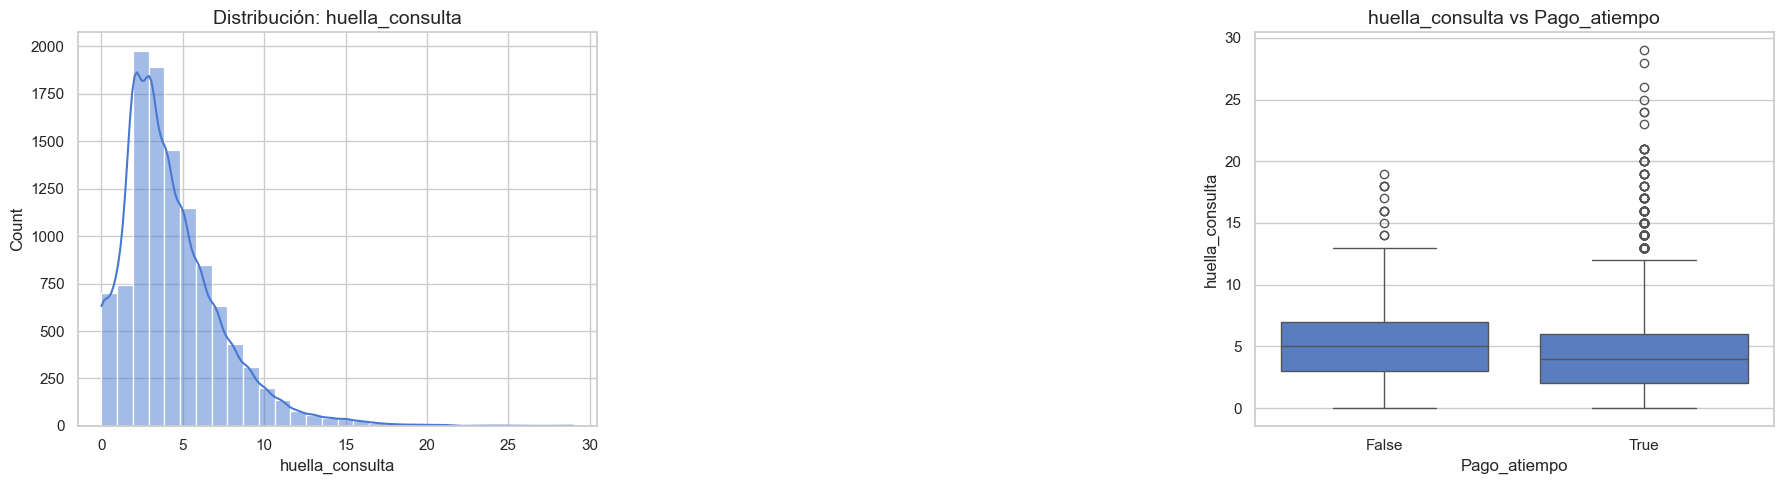


--- Estadísticas de huella_consulta ---
count   10,763.00
mean         4.23
std          3.06
min          0.00
25%          2.00
50%          4.00
75%          6.00
max         29.00
Skewness: 1.49
Kurtosis: 4.00
% Outliers (método IQR): 2.01%


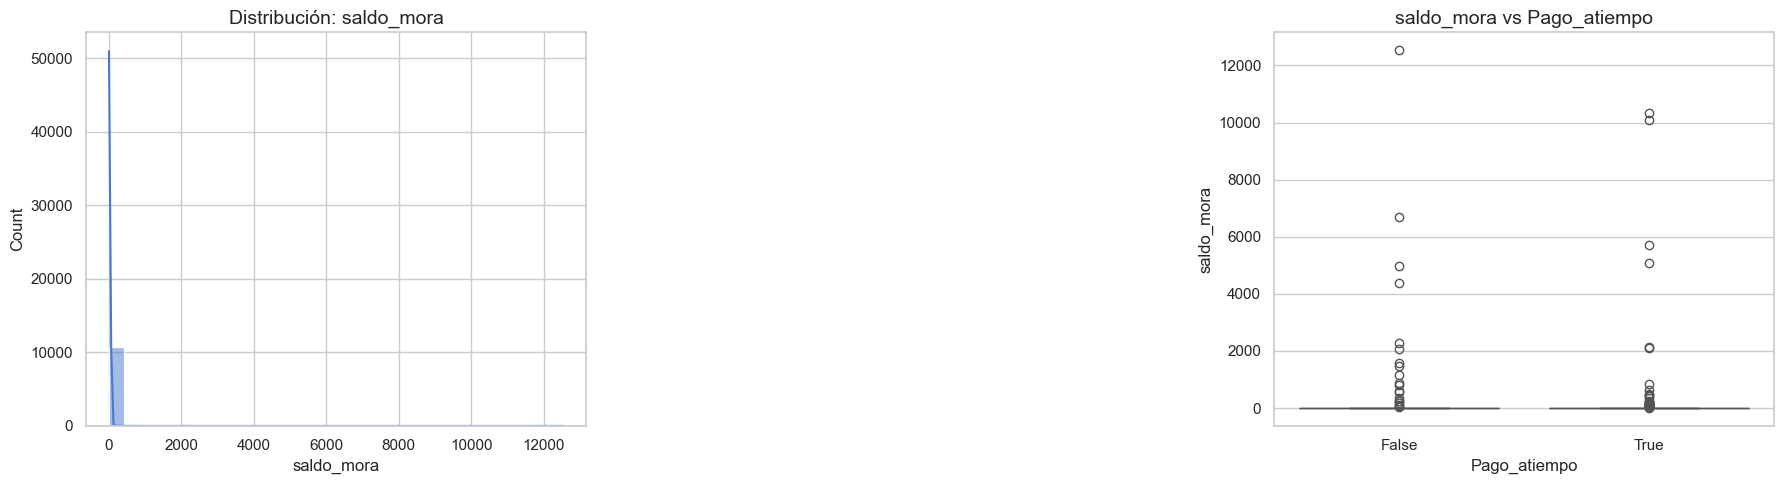


--- Estadísticas de saldo_mora ---
count   10,763.00
mean         7.63
std        224.31
min          0.00
25%          0.00
50%          0.00
75%          0.00
max     12,534.00
Skewness: 40.87
Kurtosis: 1872.91
% Outliers (método IQR): 0.51%


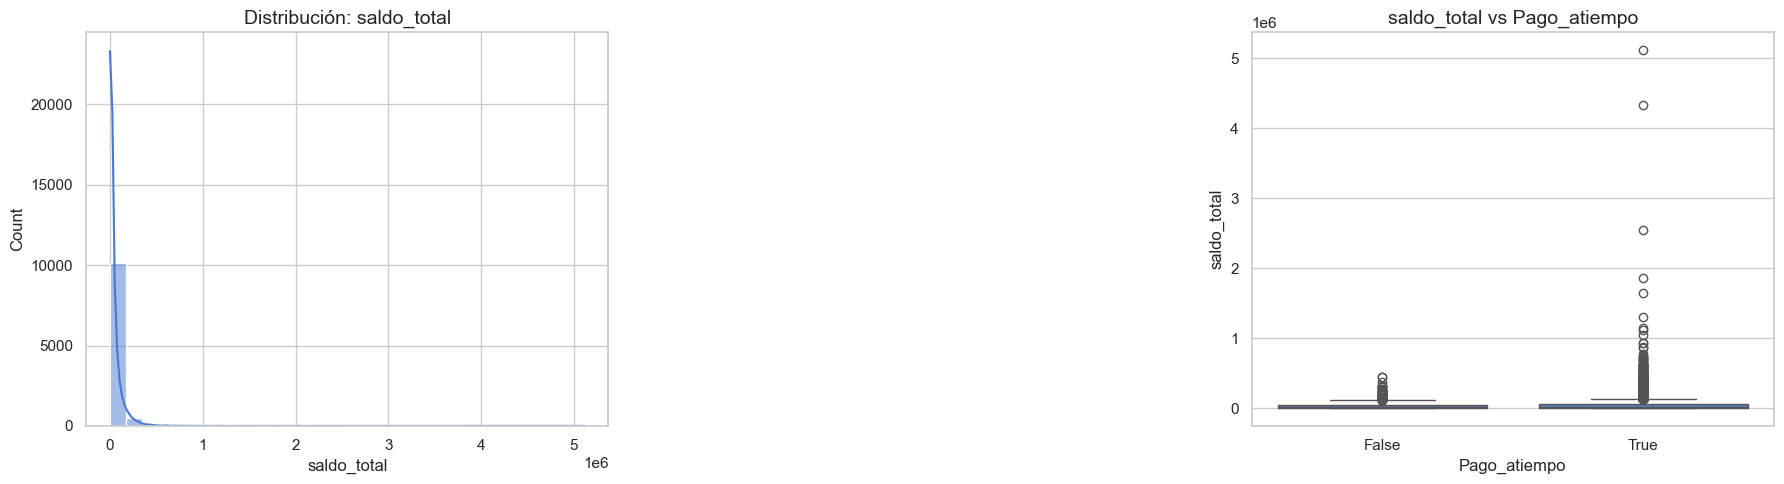


--- Estadísticas de saldo_total ---
count      10,763.00
mean       45,506.07
std       105,556.71
min             0.00
25%         3,025.00
50%        16,178.00
75%        52,156.00
max     5,116,066.00
Skewness: 20.32
Kurtosis: 799.32
% Outliers (método IQR): 9.21%


In [15]:
# ==============================================
# 6. EDA: Análisis Univariable Numérico
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def eda_univariable_numerico(df, columnas, target='Pago_atiempo'):
    """
    Análisis univariable avanzado para variables numéricas.
    - Diferencia discreta vs continua
    - Incluye escala log si aplica
    - Muestra relación con target
    - Calcula outliers por IQR y skew/kurtosis
    """
    for col in columnas:
        if col not in df.columns:
            print(f"Columna '{col}' no existe → se salta")
            continue
        
        serie = df[col].dropna()  # Evitamos nulos para cálculos estadísticos
        if len(serie) == 0:
            print(f"Columna '{col}' está completamente vacía → se salta")
            continue
        
        unique_vals = serie.nunique()
        # Detección de discreta (mejorada)
        es_discreta = (unique_vals <= 20) and (serie % 1 == 0).all()
        
        # Figura con 3 paneles
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Histograma / Countplot
        if es_discreta:
            sns.countplot(x=col, data=df, ax=axes[0], order=sorted(df[col].dropna().unique()))
            axes[0].set_title(f"Frecuencia (discreta): {col}")
        else:
            sns.histplot(serie, bins=30, kde=True, ax=axes[0])
            axes[0].set_title(f"Distribución: {col}")
        
        # 2. Escala log (solo si continua y valores >0)
        if not es_discreta and (serie > 0).all():
            sns.histplot(np.log1p(serie), bins=30, kde=True, ax=axes[1])
            axes[1].set_title(f"Log-Distribución: {col}")
        else:
            axes[1].axis('off')  # Ocultar panel si no aplica
        
        # 3. Boxplot vs target (bivariable temprano)
        if target in df.columns:
            sns.boxplot(x=target, y=col, data=df, ax=axes[2])
            axes[2].set_title(f"{col} vs {target}")
        else:
            axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Métricas detalladas (como pide la consigna)
        print(f"\n--- Estadísticas de {col} ---")
        desc = serie.describe().round(2)
        print(desc.to_string())
        
        print(f"Skewness: {serie.skew():.2f}")
        print(f"Kurtosis: {serie.kurt():.2f}")
        
        # Outliers por IQR
        q1, q3 = serie.quantile([0.25, 0.75])
        iqr = q3 - q1
        outliers_low = (serie < q1 - 1.5 * iqr).sum()
        outliers_high = (serie > q3 + 1.5 * iqr).sum()
        pct_outliers = ((outliers_low + outliers_high) / len(serie)) * 100
        print(f"% Outliers (método IQR): {pct_outliers:.2f}%")
        
        print("=" * 60)

# Ejecutar con tus columnas numéricas principales
cols_analisis = [
    'capital_prestado', 'salario_cliente', 'puntaje_datacredito', 'edad_cliente',
    'cuota_pactada', 'huella_consulta', 'saldo_mora', 'saldo_total'
]

eda_univariable_numerico(df, cols_analisis)

=== ANÁLISIS UNIVARIABLE - Categóricas / Ordinales ===

--- tipo_credito ---
tipo_credito
4      7747
9      2876
10      116
6        21
7         2
NaN       1
Name: count, dtype: int64

Porcentajes:
tipo_credito
4     71.98
9     26.72
10     1.08
6      0.20
7      0.02
NaN    0.01
Name: count, dtype: float64


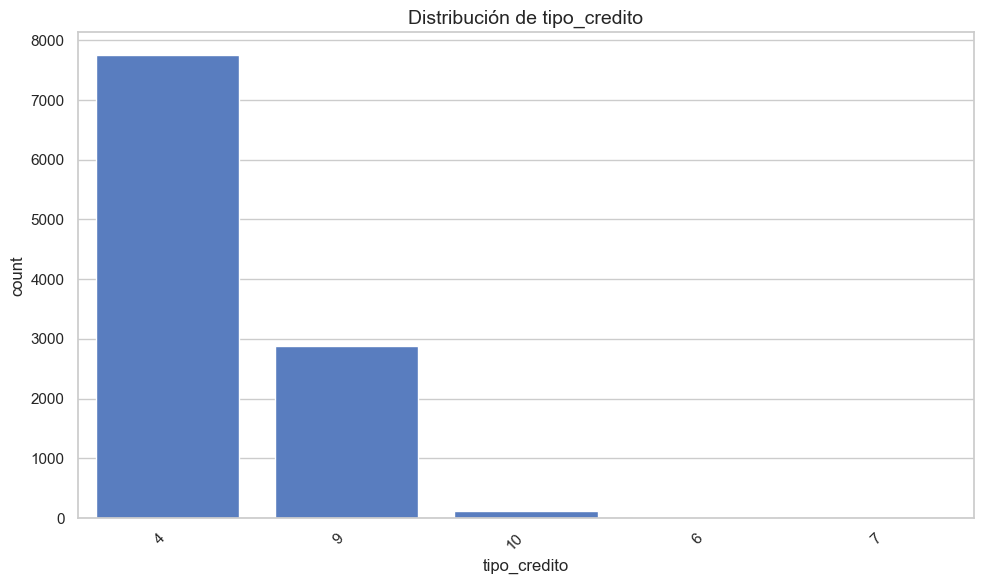

Interpretación: [ejemplo] Mayoría en 'Creciente' para tendencia_ingresos. 'Sin_dato' representa X% — revisar si correlaciona con no pago.

--- tipo_laboral ---
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

Porcentajes:
tipo_laboral
Empleado        62.75
Independiente   37.25
Name: count, dtype: float64


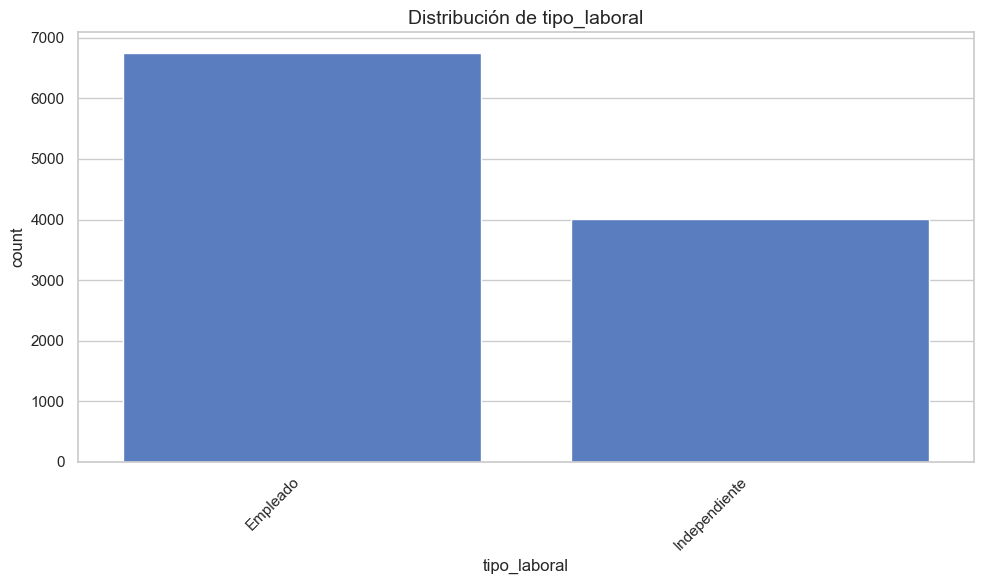

Interpretación: [ejemplo] Mayoría en 'Creciente' para tendencia_ingresos. 'Sin_dato' representa X% — revisar si correlaciona con no pago.

--- tendencia_ingresos ---
tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64

Porcentajes:
tendencia_ingresos
Creciente     49.19
NaN           27.78
Decreciente   11.99
Estable       11.04
Name: count, dtype: float64


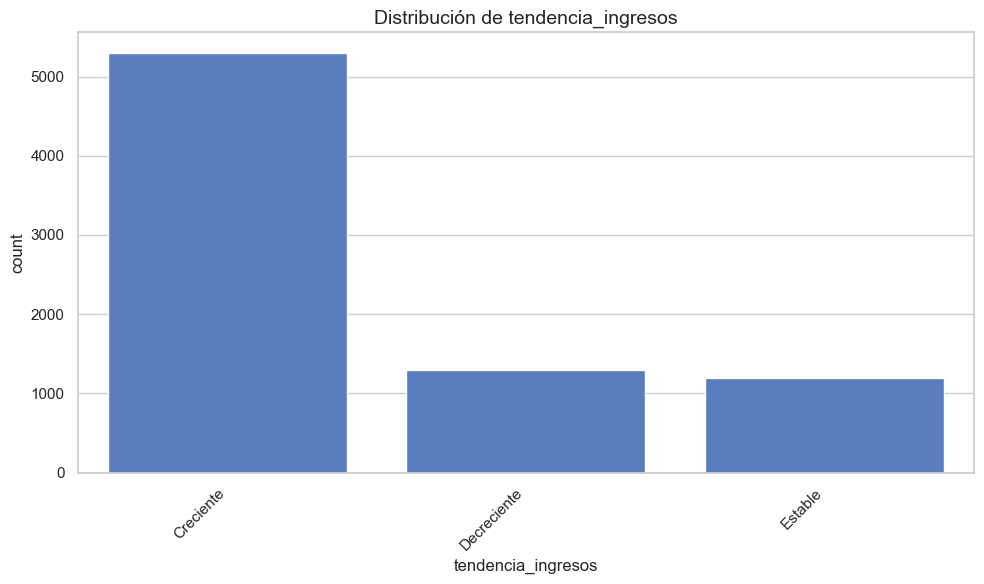

Interpretación: [ejemplo] Mayoría en 'Creciente' para tendencia_ingresos. 'Sin_dato' representa X% — revisar si correlaciona con no pago.


In [16]:
# ==============================================
# 7. EDA: Análisis Univariable Categórico / Ordinal
# ==============================================

print("=== ANÁLISIS UNIVARIABLE - Categóricas / Ordinales ===")

categoricas_para_analizar = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos']

for col in categoricas_para_analizar:
    if col in df.columns:
        print(f"\n--- {col} ---")
        conteo = df[col].value_counts(dropna=False)
        print(conteo)
        print("\nPorcentajes:")
        print((conteo / len(df) * 100).round(2))
        
        plt.figure(figsize=(10, 6))
        sns.countplot(x=df[col], order=df[col].value_counts().index)
        plt.title(f'Distribución de {col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        print("Interpretación: [ejemplo] Mayoría en 'Creciente' para tendencia_ingresos. 'Sin_dato' representa X% — revisar si correlaciona con no pago.")

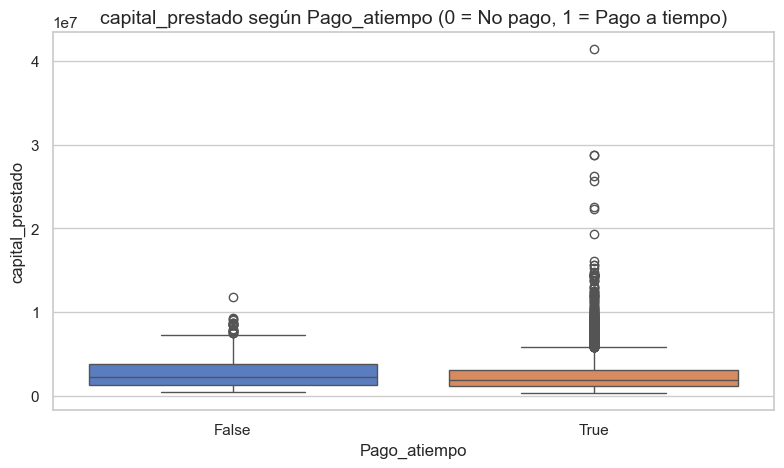


Estadísticas de capital_prestado por Pago_atiempo:
              count         mean       median          std
Pago_atiempo                                              
False           511 2,781,774.11 2,268,000.00 1,942,337.69
True          10252 2,416,996.27 1,908,446.50 1,906,438.41
→ La mediana en quienes pagan a tiempo es 359553.50 menor → posible señal de riesgo.
------------------------------------------------------------


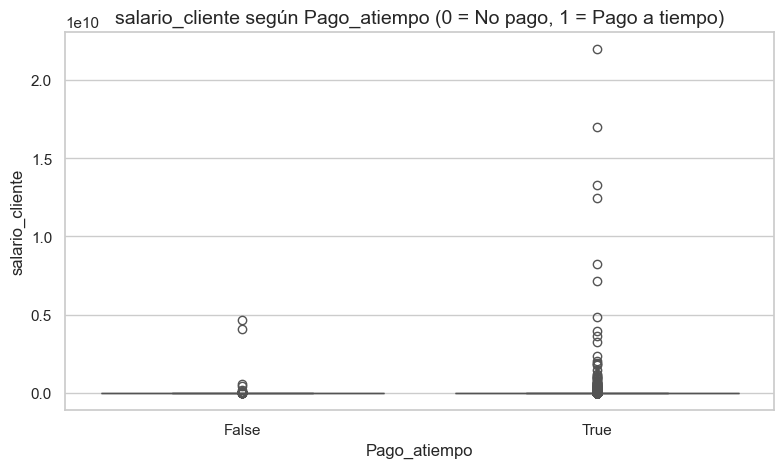


Estadísticas de salario_cliente por Pago_atiempo:
              count          mean       median            std
Pago_atiempo                                                 
False           511 23,555,143.33 3,000,000.00 274,787,635.68
True          10252 16,900,485.13 3,000,000.00 359,032,091.87
→ No hay diferencia clara en la mediana.
------------------------------------------------------------


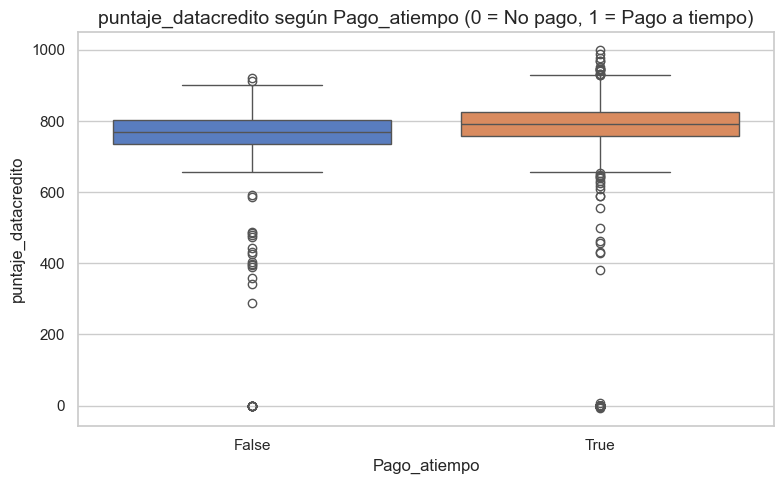


Estadísticas de puntaje_datacredito por Pago_atiempo:
              count   mean  median    std
Pago_atiempo                             
False           511 748.80  768.00 130.80
True          10252 782.34  792.00 103.15
→ La mediana en quienes pagan a tiempo es 24.00 mayor → posible señal positiva.
------------------------------------------------------------


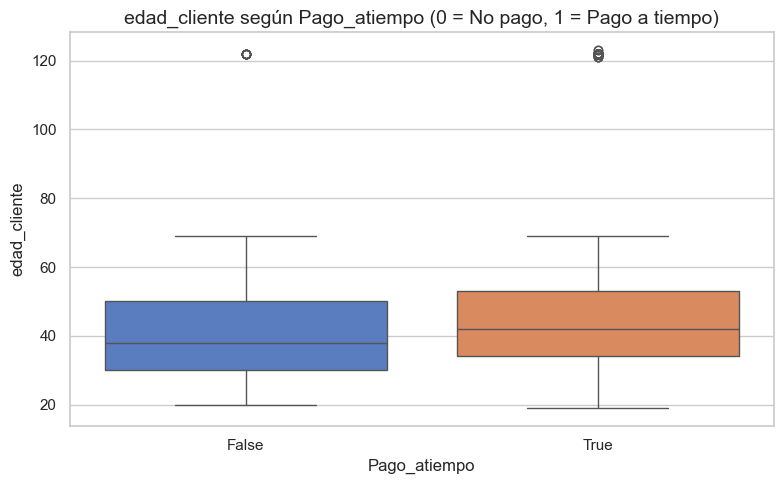


Estadísticas de edad_cliente por Pago_atiempo:
              count  mean  median   std
Pago_atiempo                           
False           511 41.77   38.00 17.06
True          10252 44.06   42.00 14.95
→ La mediana en quienes pagan a tiempo es 4.00 mayor → posible señal positiva.
------------------------------------------------------------


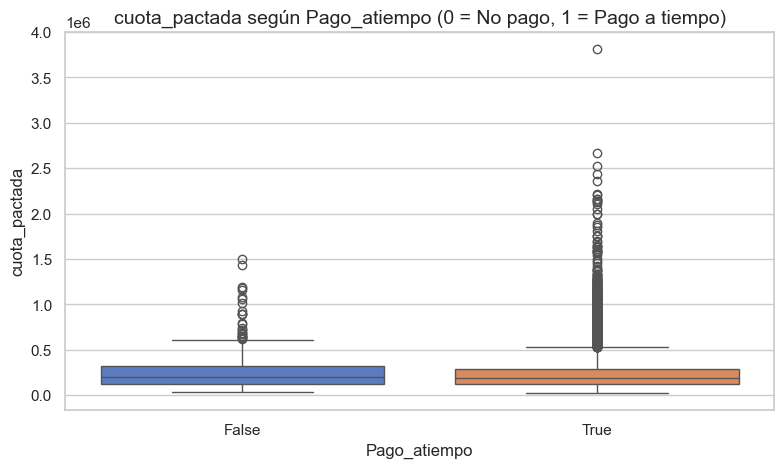


Estadísticas de cuota_pactada por Pago_atiempo:
              count       mean     median        std
Pago_atiempo                                        
False           511 254,755.69 199,002.00 201,712.00
True          10252 243,062.23 182,576.00 210,915.90
→ La mediana en quienes pagan a tiempo es 16426.00 menor → posible señal de riesgo.
------------------------------------------------------------


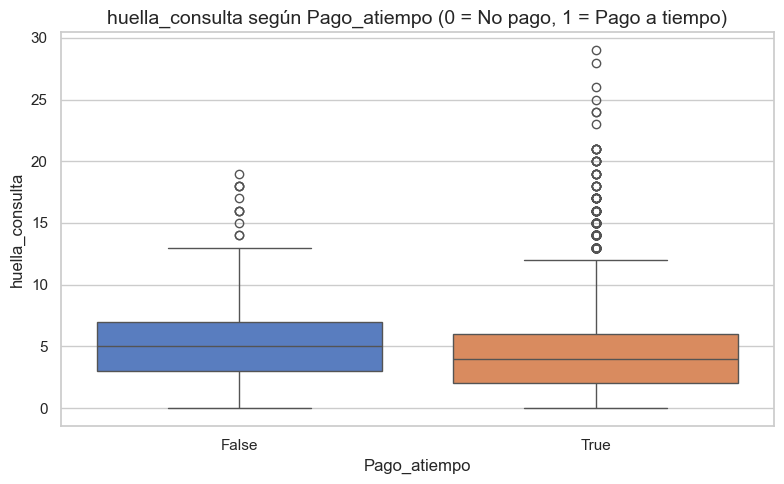


Estadísticas de huella_consulta por Pago_atiempo:
              count  mean  median  std
Pago_atiempo                          
False           511  5.24    5.00 3.45
True          10252  4.18    4.00 3.04
→ La mediana en quienes pagan a tiempo es 1.00 menor → posible señal de riesgo.
------------------------------------------------------------


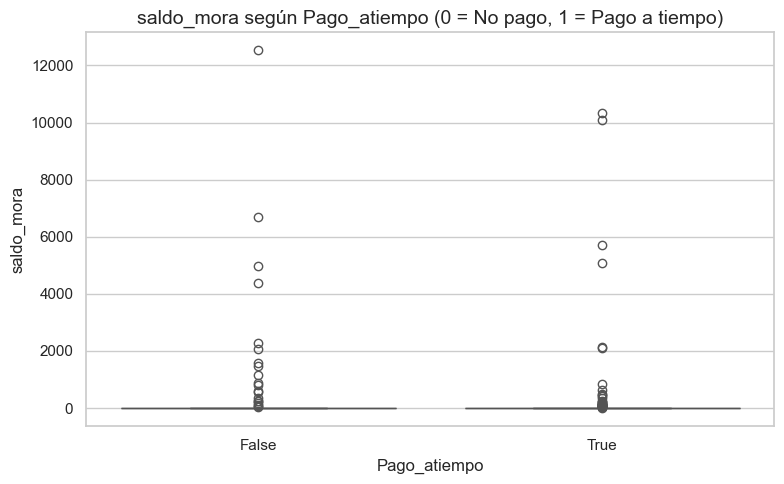


Estadísticas de saldo_mora por Pago_atiempo:
              count  mean  median    std
Pago_atiempo                            
False           511 80.59    0.00 714.82
True          10252  4.00    0.00 164.70
→ No hay diferencia clara en la mediana.
------------------------------------------------------------


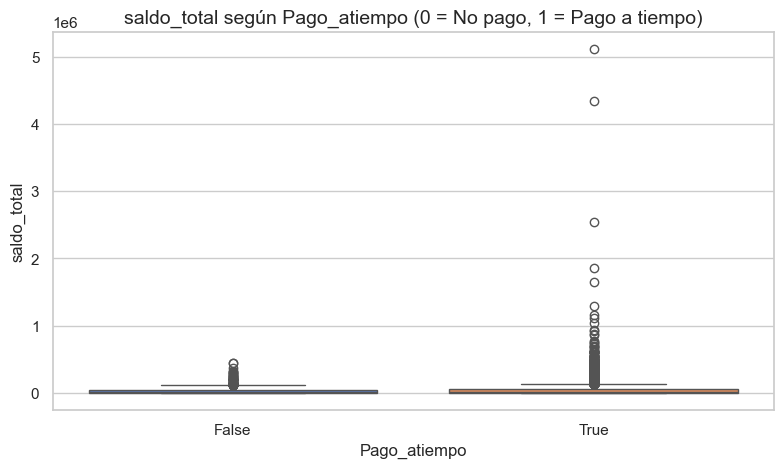


Estadísticas de saldo_total por Pago_atiempo:
              count      mean    median        std
Pago_atiempo                                      
False           511 38,582.03 14,981.00  62,786.90
True          10252 45,851.19 16,178.00 107,233.42
→ La mediana en quienes pagan a tiempo es 1197.00 mayor → posible señal positiva.
------------------------------------------------------------


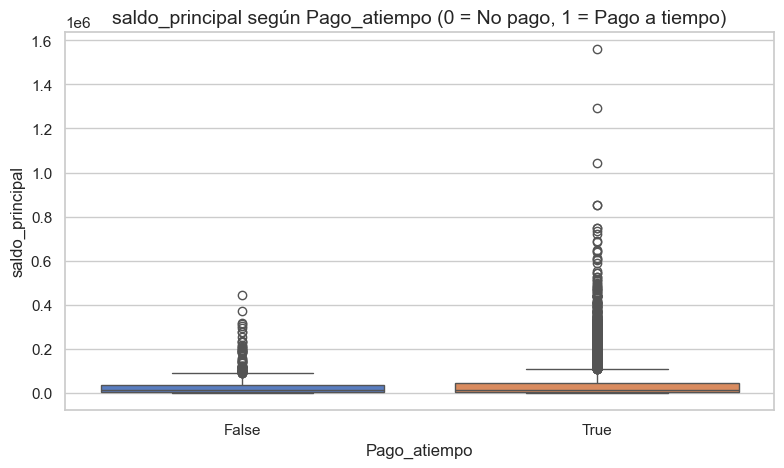


Estadísticas de saldo_principal por Pago_atiempo:
              count      mean    median       std
Pago_atiempo                                     
False           511 35,386.32 14,442.50 58,575.73
True          10252 39,570.08 14,442.50 70,582.91
→ No hay diferencia clara en la mediana.
------------------------------------------------------------


In [29]:
# ==============================================
# 7A. Análisis Bivariado: Variables Numéricas vs Target
# ==============================================

def eda_bivariado_numerico(df, columnas, target='Pago_atiempo'):
    """
    Compara variables numéricas contra el target mediante boxplots y métricas clave.
    Incluye mediana, media y comentario simple.
    """
    for col in columnas:
        if col not in df.columns:
            print(f"Columna '{col}' no existe → se salta")
            continue
        
        # Limpiamos nulos temporales para el análisis
        data_clean = df[[col, target]].dropna()
        
        if len(data_clean) == 0:
            print(f"No hay datos válidos para {col}")
            continue
        
        # Boxplot
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=data_clean, x=target, y=col, palette='muted')
        plt.title(f'{col} según {target} (0 = No pago, 1 = Pago a tiempo)')
        plt.xlabel(target)
        plt.ylabel(col)
        plt.show()
        
        # Métricas por grupo
        grouped = data_clean.groupby(target)[col].agg(['count', 'mean', 'median', 'std']).round(2)
        print(f"\nEstadísticas de {col} por {target}:")
        print(grouped)
        
        # Diferencia de medianas
        mediana_0 = grouped.loc[False, 'median'] if False in grouped.index else np.nan
        mediana_1 = grouped.loc[True, 'median'] if True in grouped.index else np.nan
        diff_mediana = mediana_1 - mediana_0 if not np.isnan(mediana_1) and not np.isnan(mediana_0) else np.nan
        
        # Comentario automático simple
        if diff_mediana > 0:
            print(f"→ La mediana en quienes pagan a tiempo es {diff_mediana:.2f} mayor → posible señal positiva.")
        elif diff_mediana < 0:
            print(f"→ La mediana en quienes pagan a tiempo es {abs(diff_mediana):.2f} menor → posible señal de riesgo.")
        else:
            print("→ No hay diferencia clara en la mediana.")
        
        print("-" * 60)

# Columnas numéricas clave para comparar vs target
cols_num_modelo = [
    'capital_prestado', 'salario_cliente', 'puntaje_datacredito', 'edad_cliente',
    'cuota_pactada', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal'
]

eda_bivariado_numerico(df, cols_num_modelo)


--- tipo_credito vs Pago_atiempo ---
Pago_atiempo  False  True  Total  % Pago (1)  % No Pago (0)
tipo_credito                                               
4               363  7384   7747       95.30           4.70
6                 9    12     21       57.10          42.90
7                 0     2      2      100.00           0.00
9               136  2740   2876       95.30           4.70
10                3   113    116       97.40           2.60


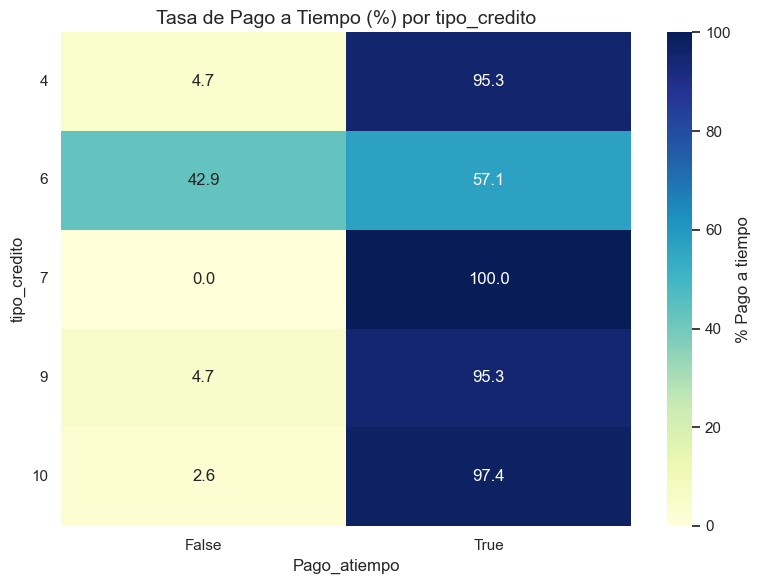

Interpretación rápida:
- Categoría con mayor tasa de pago: '7' (100.0%)
- Categoría con menor tasa de pago: '6' (57.1%)
- Diferencia: 42.9% → posible poder predictivo.

--- tipo_laboral vs Pago_atiempo ---
Pago_atiempo   False  True  Total  % Pago (1)  % No Pago (0)
tipo_laboral                                                
Empleado         290  6464   6754       95.70           4.30
Independiente    221  3788   4009       94.50           5.50


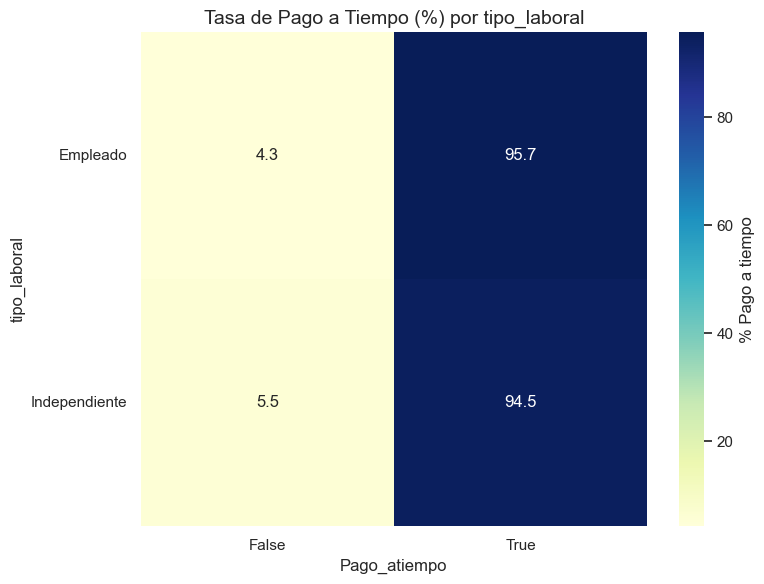

Interpretación rápida:
- Categoría con mayor tasa de pago: 'Empleado' (95.7%)
- Categoría con menor tasa de pago: 'Independiente' (94.5%)
- Diferencia: 1.2% → posible poder predictivo.

--- tendencia_ingresos vs Pago_atiempo ---
Pago_atiempo        False  True  Total  % Pago (1)  % No Pago (0)
tendencia_ingresos                                               
Decreciente            81  1210   1291       93.70           6.30
Estable                55  1133   1188       95.40           4.60
Creciente             207  5087   5294       96.10           3.90


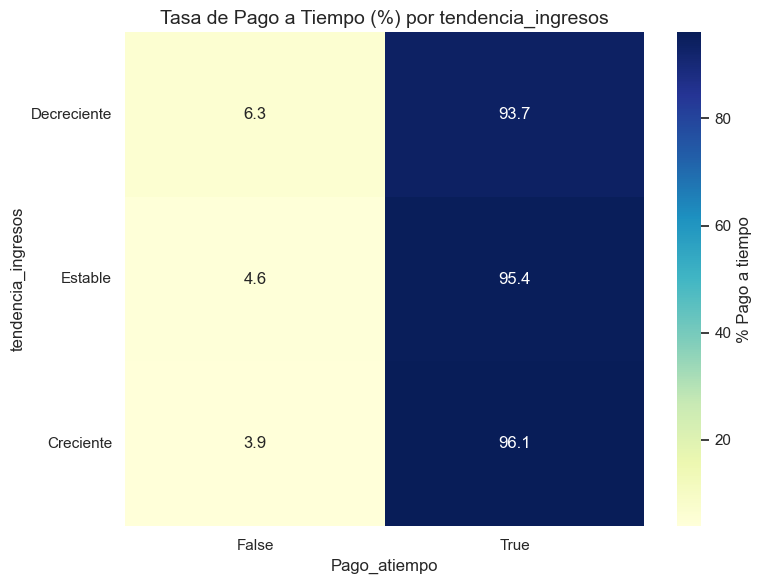

Interpretación rápida:
- Categoría con mayor tasa de pago: 'Creciente' (96.1%)
- Categoría con menor tasa de pago: 'Decreciente' (93.7%)
- Diferencia: 2.4% → posible poder predictivo.


In [30]:
# ==============================================
# 7B. Análisis Bivariado: Variables Categóricas vs Target
# ==============================================

def eda_bivariado_categorico(df, columnas, target='Pago_atiempo'):
    """
    Análisis bivariado categórico vs target:
    - Crosstab con % y conteos absolutos
    - Heatmap con tasa de pago
    - Comentario automático simple
    """
    for col in columnas:
        if col not in df.columns:
            print(f"Columna '{col}' no existe en el DataFrame → se salta")
            continue
        
        # Limpiamos nulos para este análisis
        data_clean = df[[col, target]].dropna()
        
        if len(data_clean) == 0:
            print(f"No hay datos válidos para {col}")
            continue
        
        # Crosstab con conteos y porcentajes
        crosstab_count = pd.crosstab(data_clean[col], data_clean[target])
        crosstab_pct = pd.crosstab(data_clean[col], data_clean[target], normalize='index') * 100
        
        # Combinamos en una tabla bonita
        tabla_completa = crosstab_count.copy()
        tabla_completa['Total'] = crosstab_count.sum(axis=1)
        tabla_completa['% Pago (1)'] = crosstab_pct[True].round(1) if True in crosstab_pct.columns else 0
        tabla_completa['% No Pago (0)'] = crosstab_pct[False].round(1) if False in crosstab_pct.columns else 0
        
        print(f"\n--- {col} vs {target} ---")
        print(tabla_completa)
        
        # Heatmap solo de porcentajes
        plt.figure(figsize=(8, 6))
        sns.heatmap(crosstab_pct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% Pago a tiempo'})
        plt.title(f'Tasa de Pago a Tiempo (%) por {col}')
        plt.ylabel(col)
        plt.xlabel(target)
        plt.xticks(rotation=0)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        # Comentario automático
        if len(crosstab_pct) > 1:
            tasa_max = crosstab_pct[True].max()
            categoria_max = crosstab_pct[True].idxmax()
            tasa_min = crosstab_pct[True].min()
            categoria_min = crosstab_pct[True].idxmin()
            
            print(f"Interpretación rápida:")
            print(f"- Categoría con mayor tasa de pago: '{categoria_max}' ({tasa_max:.1f}%)")
            print(f"- Categoría con menor tasa de pago: '{categoria_min}' ({tasa_min:.1f}%)")
            print(f"- Diferencia: {tasa_max - tasa_min:.1f}% → posible poder predictivo.")
        else:
            print("Solo una categoría → no hay diferencia para analizar.")
        
        print("=" * 60)

# Columnas categóricas reales de tu dataset
cols_cat_modelo = [
    'tipo_credito',
    'tipo_laboral',
    'tendencia_ingresos'
    # Agrega aquí si hay más categóricas limpias
]

eda_bivariado_categorico(df, cols_cat_modelo)

In [32]:
numericas = [
    'capital_prestado',
    'plazo_meses',
    'edad_cliente',
    'salario_cliente',
    'total_otros_prestamos',
    'cuota_pactada',
    'puntaje',
    'puntaje_datacredito',
    'cant_creditosvigentes',
    'huella_consulta',
    'saldo_mora',
    'saldo_total',
    'saldo_principal',
    'saldo_mora_codeudor',
    'creditos_sectorFinanciero',
    'creditos_sectorCooperativo',
    'creditos_sectorReal',
    'promedio_ingresos_datacredito'
]

=== ANÁLISIS MULTIVARIABLE ===


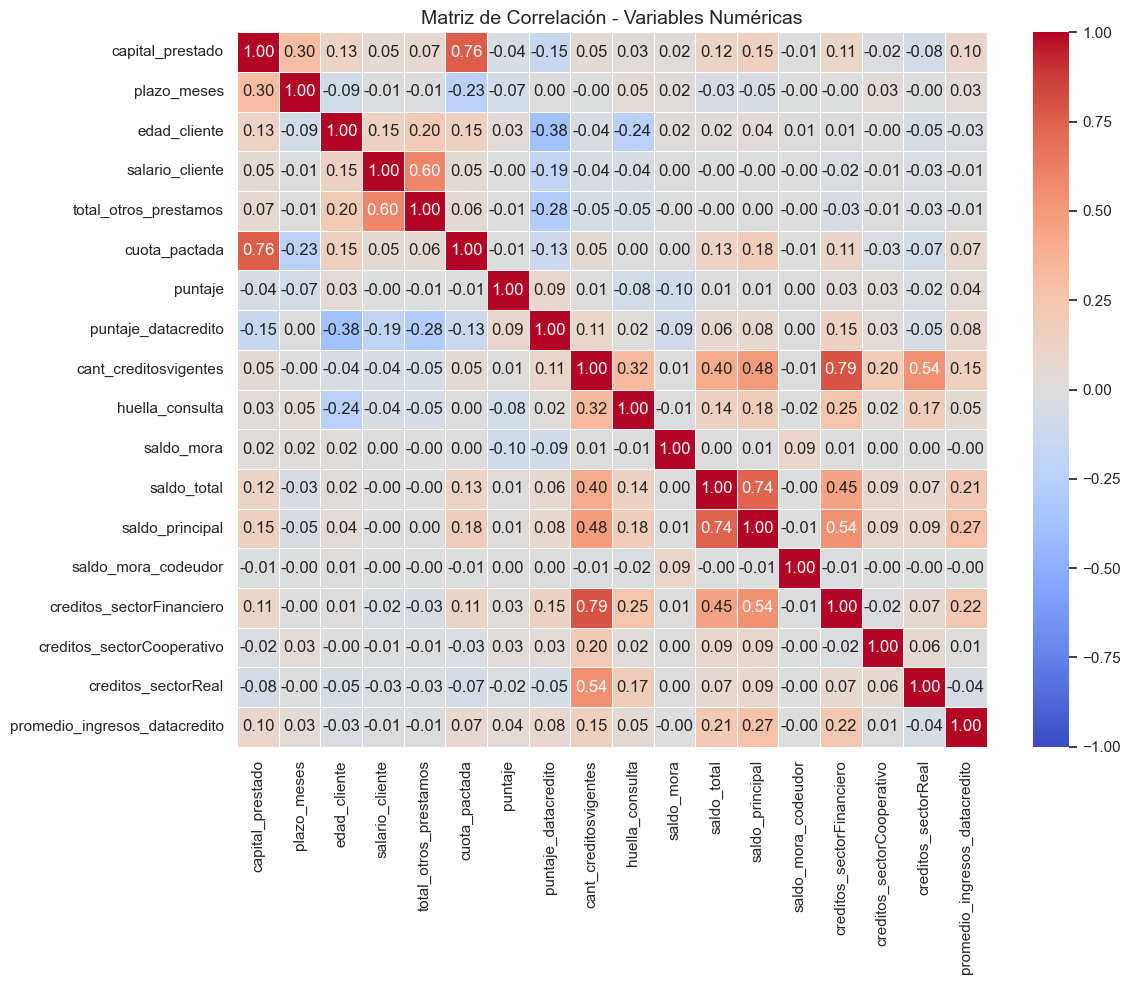

Interpretación: Correlaciones altas (>0.7) indican posible multicolinealidad (ej: saldo_total y saldo_principal). Variables con correlación fuerte con Pago_atiempo (si la hubiéramos incluido) serían candidatas clave.


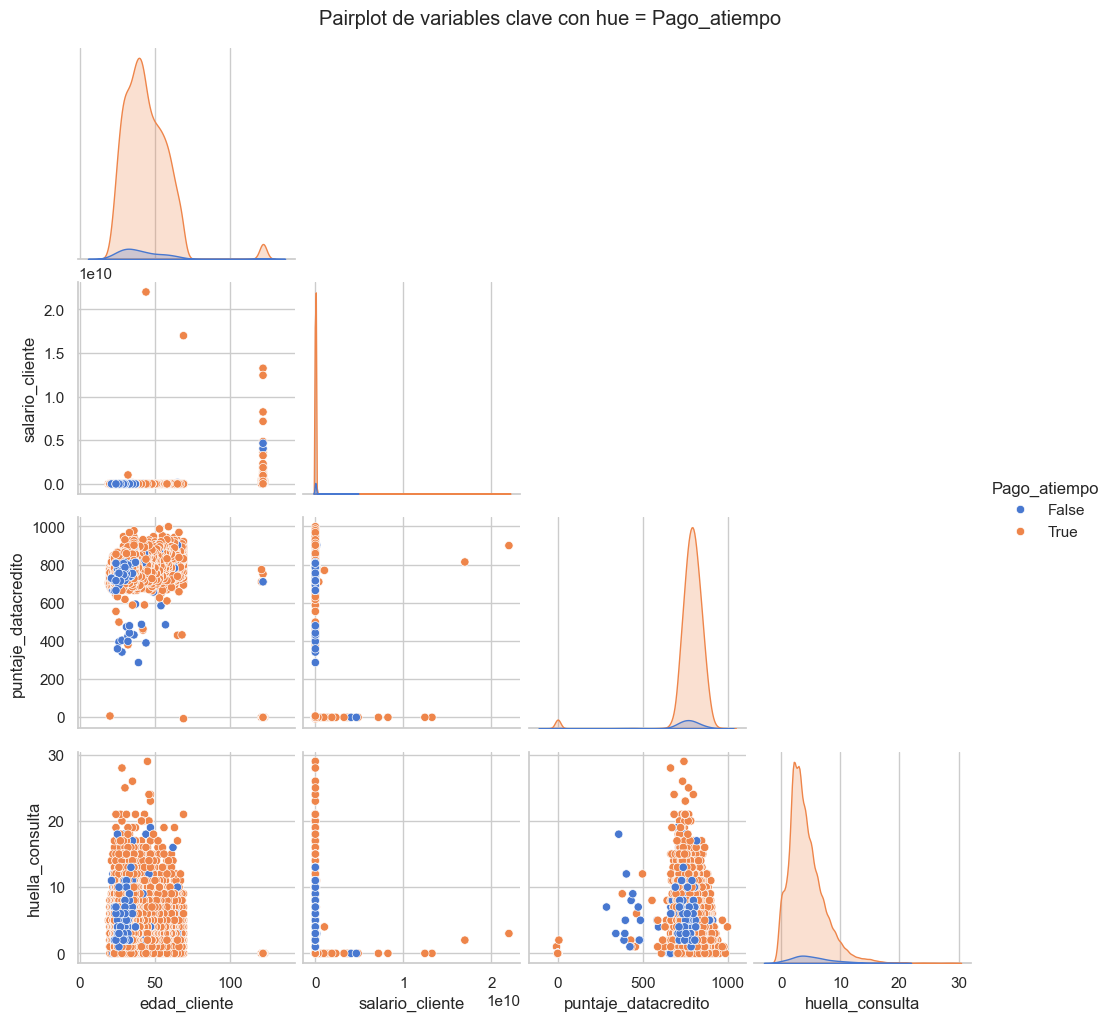

Interpretación: Observar si hay separación clara entre clases (0 vs 1) en dispersión o densidad. Ej: clientes que pagan a tiempo tienden a tener mayor salario y menor huella_consulta.


In [33]:
# ==============================================
# 8. Análisis Multivariable
# ==============================================

print("=== ANÁLISIS MULTIVARIABLE ===")

# 1. Matriz de correlación (solo numéricas)
corr = df[numericas].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

print("Interpretación: Correlaciones altas (>0.7) indican posible multicolinealidad (ej: saldo_total y saldo_principal). Variables con correlación fuerte con Pago_atiempo (si la hubiéramos incluido) serían candidatas clave.")

# 2. Pairplot con hue = target (seleccionamos pocas variables para no sobrecargar)
cols_pair = ['edad_cliente', 'salario_cliente', 'puntaje_datacredito', 'huella_consulta']  # ajusta según lo que veas importante

if target_col in df.columns:
    sns.pairplot(
        df[cols_pair + [target_col]],
        hue=target_col,
        palette='muted',
        diag_kind='kde',
        corner=True
    )
    plt.suptitle('Pairplot de variables clave con hue = Pago_atiempo', y=1.02)
    plt.show()

    print("Interpretación: Observar si hay separación clara entre clases (0 vs 1) en dispersión o densidad. Ej: clientes que pagan a tiempo tienden a tener mayor salario y menor huella_consulta.")

In [34]:
# ==============================================
# 9. Insights Finales, Reglas de Validación y Recomendaciones
# ==============================================

print("=== INSIGHTS FINALES Y RECOMENDACIONES (Avance #1 - V1.0.1) ===")

print("""
Resumen global del EDA:

1. Características principales del dataset:
   - 10.763 registros y 23 columnas.
   - Objetivo 'Pago_atiempo' es binario (0/1) con alto % de pago a tiempo (~95%) → dataset posiblemente desbalanceado.
   - Variables numéricas dominan (montos, puntajes, saldos), con alta dispersión y outliers en mora/saldos.

2. Hallazgos clave por tipo de análisis:
   - Univariado numérico: alta skew y kurtosis en variables como saldo_mora y huella_consulta → distribuciones muy asimétricas (muchos 0 + colas largas).
   - Univariado categórico: tendencia_ingresos con mayoría 'Creciente' (49%), pero 27% 'Sin dato' o 'Error_dato' → pérdida de información significativa.
   - Bivariado: tendencia_ingresos muestra diferencia clara (Creciente 96.1% pago vs Decreciente 93.7%). tipo_laboral tiene diferencia pequeña pero lógica (Empleado > Independiente).
   - Multivariable: alta correlación esperada entre saldos (saldo_total, saldo_principal, etc.) → multicolinealidad posible. Pairplot muestra separación moderada en variables como puntaje_datacredito y huella_consulta.

3. Reglas de validación sugeridas (para etapas posteriores):
   - edad_cliente: 18 ≤ edad ≤ 90 (eliminar outliers extremos).
   - capital_prestado, cuota_pactada, saldo_mora, etc.: ≥ 0 (valores negativos = error de carga).
   - huella_consulta: ≥ 0 (si negativo → revisar fuente).
   - tipo_credito: valores en rango esperado (ej: 1–10); cualquier otro (68, etc.) = 'Error_dato'.
   - Pago_atiempo: solo 0 o 1 (ya blindado como bool).
   - Si % nulos > 30% en una columna → considerar eliminación o imputación cuidadosa.

4. Transformaciones recomendadas:
   - Variables sesgadas (saldo_mora, huella_consulta, capital_prestado): aplicar log1p(x + 1) para reducir skew.
   - Normalización/escalado de numéricas antes de modelado (StandardScaler o MinMaxScaler).
   - Binarización útil: mora_positiva = 1 si saldo_mora > 0 else 0.

5. Atributos derivados sugeridos (para feature engineering):
   - ratio_cuota_salario = cuota_pactada / salario_cliente (medida de esfuerzo financiero).
   - deuda_total = saldo_total + total_otros_prestamos.
   - riesgo_huella = 1 si huella_consulta > 6 else 0 (umbral común).
   - ingreso_por_credito = salario_cliente / cant_creditosvigentes.
   - antiguedad_prestamo = (fecha actual - fecha_prestamo).days (si hay fecha actual).
   - edad_grupo = pd.cut(df['edad_cliente'], bins=[18, 30, 45, 60, 90], labels=['Joven', 'Adulto', 'Maduro', 'Senior']).

6. Observaciones finales:
   - Variables de riesgo (huella_consulta, saldo_mora, puntaje) tienen mayor poder predictivo.
   - Alta presencia de 'Sin_dato' en tendencia_ingresos → posible indicador de riesgo (analizar si correlaciona con no pago).
   - Dataset listo para modelado, pero con precaución por posible desbalance y multicolinealidad.
   - Próximo paso: feature engineering + entrenamiento de modelos (en avances siguientes).
""")

=== INSIGHTS FINALES Y RECOMENDACIONES (Avance #1 - V1.0.1) ===

Resumen global del EDA:

1. Características principales del dataset:
   - 10.763 registros y 23 columnas.
   - Objetivo 'Pago_atiempo' es binario (0/1) con alto % de pago a tiempo (~95%) → dataset posiblemente desbalanceado.
   - Variables numéricas dominan (montos, puntajes, saldos), con alta dispersión y outliers en mora/saldos.

2. Hallazgos clave por tipo de análisis:
   - Univariado numérico: alta skew y kurtosis en variables como saldo_mora y huella_consulta → distribuciones muy asimétricas (muchos 0 + colas largas).
   - Univariado categórico: tendencia_ingresos con mayoría 'Creciente' (49%), pero 27% 'Sin dato' o 'Error_dato' → pérdida de información significativa.
   - Bivariado: tendencia_ingresos muestra diferencia clara (Creciente 96.1% pago vs Decreciente 93.7%). tipo_laboral tiene diferencia pequeña pero lógica (Empleado > Independiente).
   - Multivariable: alta correlación esperada entre saldos (saldo_tota